In [4]:
import pandas as pd

df = pd.read_excel("Dataset/ModernSamples/GeneticDistances.xlsx")
df.dtypes

Era               str
Population        str
Year (BP)       int64
Region            str
Lat           float64
Long          float64
CultureID       int64
Dist          float64
dtype: object

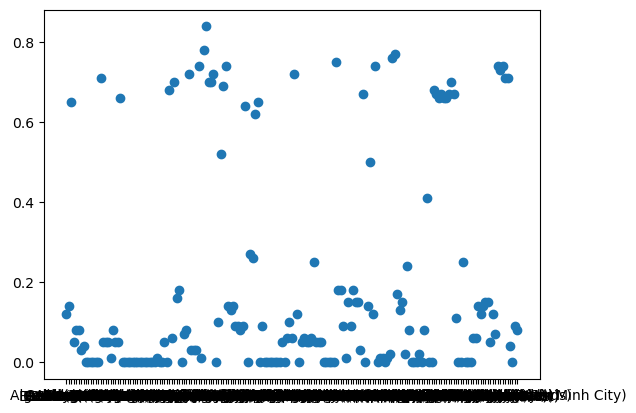

In [26]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file("Dataset/ModernSamples/GeneticDistances.xlsx")
plt.scatter(gdf["Population"], gdf["Dist"])

In [10]:
import geopandas as gpd

gdf = gpd.read_file("Dataset/AADR Annotations 2025.xlsx")
gdf.dtypes

#                                                                                                                                                                                                                                                                 int32
Genetic ID                                                                                                                                                                                                                                                          str
Master ID                                                                                                                                                                                                                                                           str
Skeletal code                                                                                                                                                                                                   

In [12]:
gdf["Method for Determining Date; unless otherwise specified, calibrations use 95.4% intervals from OxCal v4.4.2 Bronk Ramsey (2009); r5; Atmospheric data from Reimer et al (2020)"].unique()


<StringArray>
[                                                                                                                                                                                                                 'Direct IntCal20',
                                                                                                                                                                                                                 'Direct: IntCal20',
                                                                                                                                                                                              'Context: Main period of tumulus use',
 'Context: Date(s) on individuals with >20cM IBD stretches (I13835, I13836, I13837); ignore a date that must be wrong also due to the very unexpected ancestry of 1121-936 calBCE (2870±20 BP, PSUAMS-5941) calibrated as IntCal20',
                                                                      

In [35]:
import pandas as pd
import geopandas
import matplotlib.pyplot as plt
from geodatasets import get_path

gdf = geopandas.GeoDataFrame(
    df, geometry=geopandas.points_from_xy(df.Long, df.Lat), crs="EPSG:4326"
)

gdf

,Era,Population,Year (BP),Region,Lat,Long,CultureID,Dist,geometry
0,Modern,Abkhazia,0,Caucasus,42.97,41.44,1000,0.12,POINT (41.44 42.97)
1,Modern,Adygei,0,Caucasus,44.00,39.00,1000,0.14,POINT (39 44)
2,Modern,Albania,0,Europe_West,41.30,19.80,1000,0.65,POINT (19.8 41.3)
3,Modern,Algeria (Mozabite),0,Africa_North,32.00,3.00,1000,0.05,POINT (3 32)
4,Modern,Armenia,0,Caucasus,40.06,45.03,1000,0.08,POINT (45.03 40.06)
...,...,...,...,...,...,...,...,...,...
180,Modern,Ukraine (West),0,Europe_East,49.90,24.00,1000,0.71,POINT (24 49.9)
181,Modern,Uzbekistan,0,Asia_Central,41.37,64.58,1000,0.04,POINT (64.58 41.37)
182,Modern,"Vietnam (Kinh, Ho Chi Minh City)",0,Asia_Southeast,10.75,106.52,1000,0.00,POINT (106.52 10.75)
183,Modern,Yemen,0,Arabia,14.00,44.60,1000,0.09,POINT (44.6 14)


<Axes: >

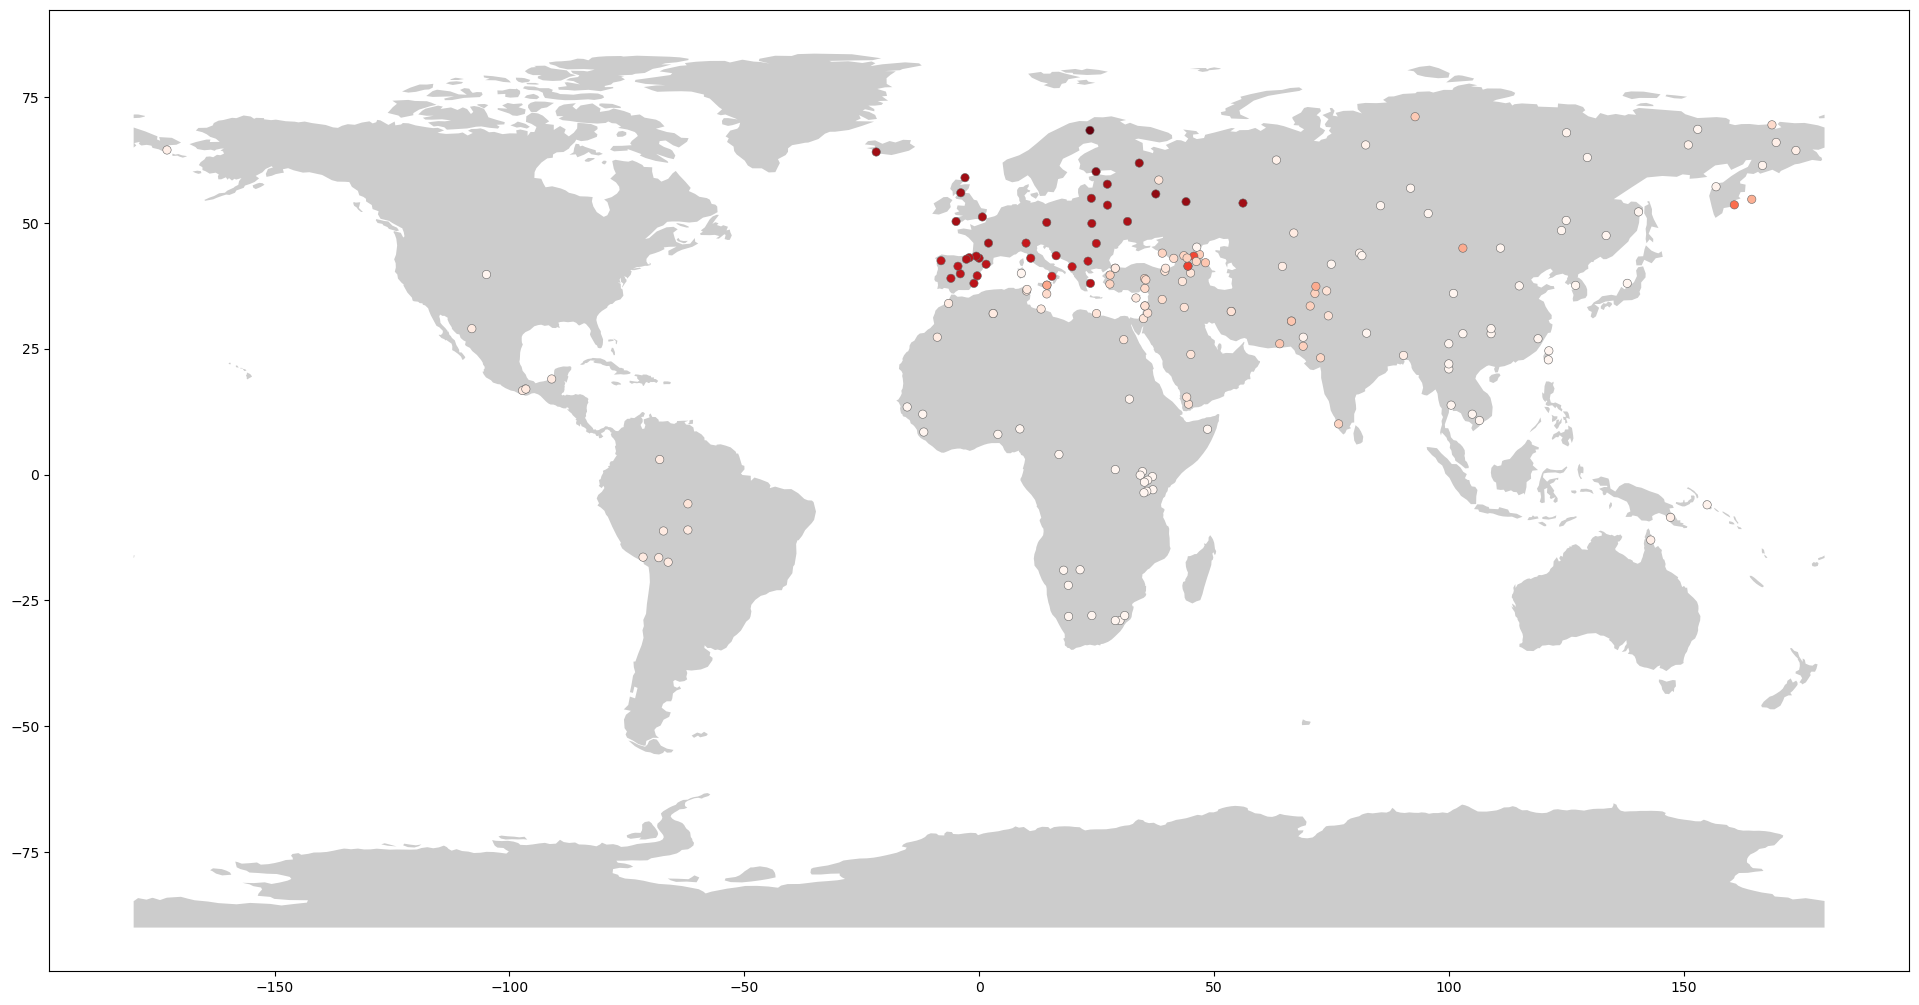

In [47]:
world = geopandas.read_file(get_path("naturalearth.land"))
# ax = world.plot(color="white", edgecolor="black")
fig, ax = plt.subplots(figsize=(24, 18))
world.plot(ax=ax, alpha=0.4, color="grey")
gdf.plot(ax=ax, column="Dist", cmap="Reds", linewidth=0.4, edgecolor=".4")
# plt.show()

In [ ]:
import folium 
from folium import plugins

map = folium.Map(location=[15, 30], tiles="Cartodb dark_matter", zoom_start=2)

heat_data = [[point.xy[1][0], point.xy[0][0]] for point in gdf.geometry]

heat_data
plugins.HeatMap(heat_data, radius=15).add_to(map)

map.save("test.html")

In [38]:
import numpy as np
from scipy.interpolate import griddata

# Grid covering world
lon_grid = np.linspace(-180, 180, 500)
lat_grid = np.linspace(-60, 85, 300)
grid_lon, grid_lat = np.meshgrid(lon_grid, lat_grid)

# Interpolate
grid_z = griddata(
    points=(gdf["Long"], gdf["Lat"]),
    values=gdf["Dist"],
    xi=(grid_lon, grid_lat),
    method="cubic"   # smoothest
)

/home/inf-43-2025/miniconda3/envs/heatmap/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/inf-43-2025/miniconda3/envs/heatmap/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/inf-43-2025/miniconda3/envs/heatmap/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


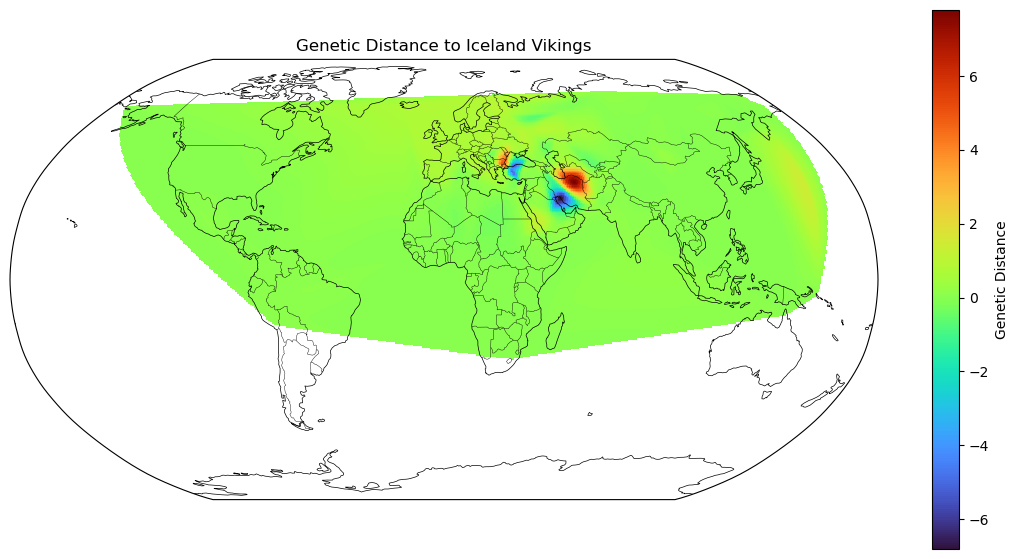

In [40]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(14,7))
ax = plt.axes(projection=ccrs.Robinson())  # nice world projection

# Heat surface
heat = ax.pcolormesh(
    grid_lon, grid_lat, grid_z,
    transform=ccrs.PlateCarree(),
    cmap="turbo",          # similar to your image
    shading="auto"
)

# Map styling
ax.add_feature(cfeature.LAND, facecolor="none")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.set_global()

plt.colorbar(heat, label="Genetic Distance")
plt.title("Genetic Distance to Iceland Vikings")

plt.show()

In [ ]:
import numpy as np

df["TimeBin"] = 1950 - ((df["Year_BP"] // 100) * 100)

In [32]:
import matplotlib.pyplot as plt
import geopandas as gpd
from geodatasets import get_path

world = gpd.read_file(get_path("naturalearth.land"))


fig, ax = plt.subplots(figsize=(10,6))
world.plot(ax=ax, color="lightgrey")

sc = ax.scatter(
    gdf["Long"], gdf["Lat"],
    c=gdf["Dist"],
    cmap="jet",
    s=80
)

plt.colorbar(sc, label="Genetic Distance to Iceland Vikings")
#plt.title(f"Genetic Similarity Map — {t}-{t+100} BP")

plt.savefig("modern.png")
plt.close()

In [27]:
from matplotlib import colormaps
list(colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',